# Predicting ad Click-Through Rate with logistic regression (SGD)

You are interviewing with an ad team. The task: predict the **click-through rate
(CTR)** of an ad from categorical context (site, app, device, position, hour). The
classic benchmark is the [Avazu CTR dataset](https://www.kaggle.com/competitions/avazu-ctr-prediction/data);
the markdown below shows how to plug it in. So the notebook runs anywhere, it
also ships a synthetic generator that mirrors the Avazu schema (high-cardinality
IDs and a realistic ~17% click rate).

**You will implement**
- the **hashing trick** for high-cardinality categorical features,
- the log-loss gradient (derived by hand) and **logistic regression trained with SGD**,
- imbalance-aware evaluation: log-loss, the **precision-recall** curve, average precision,

**and then investigate**
- how the hash dimension trades memory against collisions, and
- whether your predicted probabilities are **calibrated** (which ad auctions require).


## Setup

In [1]:
%matplotlib inline
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

## The data

Real CTR features are mostly high-cardinality categoricals (IDs with thousands to millions of values) and the positive class is rare. The generator below produces data with those properties; the commented lines show how to load the real Avazu CSV instead.

In [2]:
# Columns mirror a slimmed-down Avazu schema. The first few are high-cardinality
# (like site_id / app_id / device_id); the rest are low-cardinality context.
CARD = {
    "site_id": 1500, "app_id": 1200, "device_id": 6000,
    "site_category": 22, "app_category": 18,
    "device_type": 5, "banner_pos": 4, "hour": 24,
}
CAT_COLS = list(CARD)


def _calibrate_bias(logit, target):
    lo, hi = -20.0, 20.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if sigmoid(logit + mid).mean() < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def make_ctr_data(n=30000, target_ctr=0.17, seed=0):
    """Synthetic click-through data that mimics the Avazu schema.

    Click probability is driven by per-value latent weights plus one
    category interaction, then the intercept is calibrated so the overall
    click rate is ~target_ctr (a realistically imbalanced problem).
    Returns a DataFrame of string categorical columns plus a 0/1 `click`.
    """
    g = np.random.default_rng(seed)
    # a few columns carry more signal than others
    scale = {"site_id": 0.5, "app_id": 0.5, "device_id": 0.2, "site_category": 0.8,
             "app_category": 0.7, "device_type": 0.4, "banner_pos": 0.6, "hour": 0.3}
    latent = {c: g.normal(0, scale[c], size=CARD[c]) for c in CAT_COLS}
    vals = {c: g.integers(0, CARD[c], size=n) for c in CAT_COLS}

    logit = np.zeros(n)
    for c in CAT_COLS:
        logit += latent[c][vals[c]]
    # interaction: certain (site_category, device_type) pairs click more
    inter = g.normal(0, 0.7, size=(CARD["site_category"], CARD["device_type"]))
    logit += inter[vals["site_category"], vals["device_type"]]

    logit += _calibrate_bias(logit, target_ctr)
    click = (g.random(n) < sigmoid(logit)).astype(int)
    df = pd.DataFrame({c: [f"{c}_{v}" for v in vals[c]] for c in CAT_COLS})
    df["click"] = click
    return df

In [3]:
df = make_ctr_data(n=30000, target_ctr=0.17, seed=0)
print("rows:", len(df), "| click rate:", round(df['click'].mean(), 3))
print("unique device_id values:", df['device_id'].nunique())
df.head()

# ---------------------------------------------------------------------------
# To use the REAL data instead, accept the Avazu competition on Kaggle, then:
#     df = pd.read_csv("train.gz", nrows=300_000)
#     df = df.rename(columns={"click": "click"})  # already named `click`
# Keep CAT_COLS to the categorical columns you want to hash; everything below
# works unchanged on the real frame.
# ---------------------------------------------------------------------------

rows: 30000 | click rate: 0.17
unique device_id values: 5957


,site_id,app_id,device_id,site_category,app_category,device_type,banner_pos,hour,click
0,site_id_1009,app_id_340,device_id_1902,site_category_20,app_category_2,device_type_4,banner_pos_2,hour_1,0
1,site_id_779,app_id_628,device_id_4977,site_category_12,app_category_9,device_type_0,banner_pos_3,hour_3,0
2,site_id_4,app_id_1123,device_id_5264,site_category_6,app_category_15,device_type_4,banner_pos_2,hour_15,0
3,site_id_1018,app_id_970,device_id_983,site_category_14,app_category_7,device_type_2,banner_pos_1,hour_15,0
4,site_id_1265,app_id_186,device_id_4121,site_category_9,app_category_0,device_type_1,banner_pos_2,hour_3,0


In [4]:
def train_test_split(df, test_size=0.3, seed=123):
    idx = np.arange(len(df))
    np.random.default_rng(seed).shuffle(idx)
    n_test = int(round(test_size * len(df)))
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)


train_df, test_df = train_test_split(df)
y_train = train_df["click"].to_numpy()
y_test = test_df["click"].to_numpy()
len(train_df), len(test_df)

(21000, 9000)

## Task 1 - The hashing trick

Map each `column=value` token to one of `D` buckets with a stable hash. This is how CTR models handle features with huge, open-ended vocabularies.

In [5]:
def _stable_bucket(token, D):
    digest = hashlib.blake2b(token.encode("utf-8"), digest_size=8).digest()
    return int.from_bytes(digest, "little") % D


def hash_row(row, cols, D):
    """Return the list of active bucket indices for one row."""
    return [_stable_bucket(f"{col}={row[col]}", D) for col in cols]


def build_index_matrix(frame, cols, D):
    """Apply the hashing trick to every row -> shape (n, len(cols))."""
    X_idx = np.empty((len(frame), len(cols)), dtype=np.int64)
    for j, col in enumerate(cols):
        values = frame[col].astype(str).to_numpy()
        X_idx[:, j] = [_stable_bucket(f"{col}={value}", D) for value in values]
    return X_idx


## Task 2 - Derive the gradient

Write logistic regression for a single example with multi-hot feature vector
$\mathbf{x}$ (here, ones at the hashed buckets), weights $\mathbf{w}$, bias $b$:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad p = \sigma(z), \qquad
\ell = -\big(y \log p + (1-y)\log(1-p)\big).$$

Derive $\dfrac{\partial \ell}{\partial \mathbf{w}}$ and $\dfrac{\partial \ell}{\partial b}$,
and explain what the update looks like for the **hashed** representation where only a
handful of entries of $\mathbf{x}$ are nonzero. Write your derivation in the cell below.


For one example,

\[
z=\mathbf{w}^{\top}\mathbf{x}+b,\qquad p=\sigma(z),
\]

and

\[
\ell=-\left[y\log p+(1-y)\log(1-p)\right].
\]

The chain rule gives

\[
\frac{\partial \ell}{\partial z}=p-y.
\]

Since \(\partial z/\partial \mathbf{w}=\mathbf{x}\) and
\(\partial z/\partial b=1\),

\[
\boxed{\frac{\partial \ell}{\partial \mathbf{w}}=(p-y)\mathbf{x}},
\qquad
\boxed{\frac{\partial \ell}{\partial b}=p-y}.
\]

Thus the SGD update is

\[
\mathbf{w}\leftarrow\mathbf{w}-\eta(p-y)\mathbf{x},
\qquad
b\leftarrow b-\eta(p-y).
\]

A hashed row activates only one bucket per categorical field, so only those few
weights are updated. When two tokens collide, the repeated bucket receives both
gradient contributions. The work per row depends on the number of active fields,
not on the total feature vocabulary.


## Task 3 - Logistic regression with SGD

Implement the training loop from the gradient you derived. Update only the active (hashed) weights.

In [6]:
def train_logreg_sgd(X_idx, y, D, lr=0.1, epochs=3, l2=1e-6, seed=0):
    """From-scratch SGD logistic regression over hashed features."""
    w = np.zeros(D, dtype=float)
    b = 0.0
    g = np.random.default_rng(seed)

    for _ in range(epochs):
        for i in g.permutation(len(y)):
            active = X_idx[i]
            p = sigmoid(b + w[active].sum())
            error = p - y[i]
            if l2:
                w[active] *= (1.0 - lr * l2)
            np.add.at(w, active, -lr * error)
            b -= lr * error
    return w, b


def predict_proba(X_idx, w, b):
    """Vectorized probabilities: sigmoid(b + sum of active weights)."""
    return sigmoid(b + w[X_idx].sum(axis=1))


## Task 4 - Evaluation under class imbalance

With ~17% positives, accuracy is meaningless. Implement log-loss and the precision-recall curve, then evaluate.

In [7]:
def log_loss(y, p, eps=1e-12):
    """Mean binary cross-entropy."""
    y = np.asarray(y, dtype=float)
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return -np.mean(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))


def pr_curve(y, p):
    """Return recall and precision while sweeping threshold high to low."""
    y = np.asarray(y, dtype=int)
    order = np.argsort(-np.asarray(p), kind="mergesort")
    ys = y[order]
    tp = np.cumsum(ys)
    fp = np.cumsum(1 - ys)
    total_pos = y.sum()
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / total_pos if total_pos else np.zeros_like(tp, dtype=float)
    return np.r_[0.0, recall], np.r_[1.0, precision]


def average_precision(y, p):
    """Non-interpolated average precision."""
    y = np.asarray(y, dtype=int)
    total_pos = y.sum()
    if total_pos == 0:
        return 0.0
    ys = y[np.argsort(-np.asarray(p), kind="mergesort")]
    precision = np.cumsum(ys) / np.arange(1, len(ys) + 1)
    return float((precision * ys).sum() / total_pos)


baseline log-loss (predict the base rate 0.171): 0.4503
model log-loss:    0.4111
model avg precision (PR-AUC): 0.3444
positives in test: 0.166  (so 'always no-click' has 0.834 accuracy)


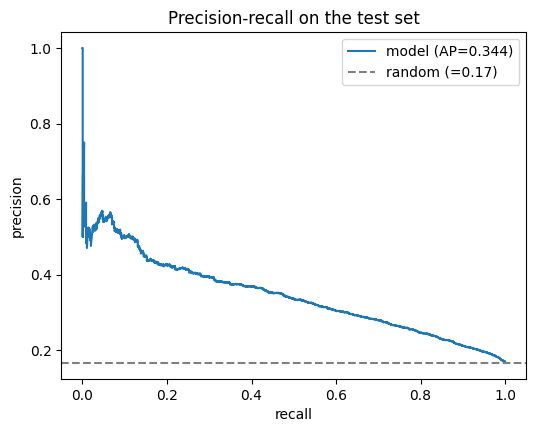

In [8]:
D = 2 ** 18
Xtr = build_index_matrix(train_df, CAT_COLS, D)
Xte = build_index_matrix(test_df, CAT_COLS, D)
w, b = train_logreg_sgd(Xtr, y_train, D, lr=0.1, epochs=3)

p_te = predict_proba(Xte, w, b)
base_rate = y_train.mean()
print(f"baseline log-loss (predict the base rate {base_rate:.3f}): "
      f"{log_loss(y_test, np.full_like(p_te, base_rate)):.4f}")
print(f"model log-loss:    {log_loss(y_test, p_te):.4f}")
print(f"model avg precision (PR-AUC): {average_precision(y_test, p_te):.4f}")
print(f"positives in test: {y_test.mean():.3f}  (so 'always no-click' has {1-y_test.mean():.3f} accuracy)")

rec, prec = pr_curve(y_test, p_te)
plt.figure(figsize=(6, 4.5))
plt.plot(rec, prec, label=f"model (AP={average_precision(y_test, p_te):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"random (={y_test.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision-recall on the test set"); plt.legend()
plt.show()

## Task 5 - Does the hash dimension matter?

The heart of the assignment: sweep `D` and watch collisions trade off against memory.

In [9]:
# Centerpiece: how does the hash dimension D trade memory against collisions?
Ds = [2 ** 8, 2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16, 2 ** 18]
ap_by_D, ll_by_D = [], []
for Dk in Ds:
    Xtr_k = build_index_matrix(train_df, CAT_COLS, Dk)
    Xte_k = build_index_matrix(test_df, CAT_COLS, Dk)
    w_k, b_k = train_logreg_sgd(Xtr_k, y_train, Dk, lr=0.1, epochs=3, l2=1e-6, seed=0)
    p_k = predict_proba(Xte_k, w_k, b_k)
    ap_by_D.append(average_precision(y_test, p_k))
    ll_by_D.append(log_loss(y_test, p_k))

for Dk, ap, ll in zip(Ds, ap_by_D, ll_by_D):
    print(f"D=2^{int(np.log2(Dk)):>2}  AP={ap:.3f}  logloss={ll:.4f}")


D=2^ 8  AP=0.284  logloss=0.4349
D=2^10  AP=0.303  logloss=0.4350
D=2^12  AP=0.316  logloss=0.4261
D=2^14  AP=0.330  logloss=0.4170
D=2^16  AP=0.341  logloss=0.4127
D=2^18  AP=0.344  logloss=0.4111


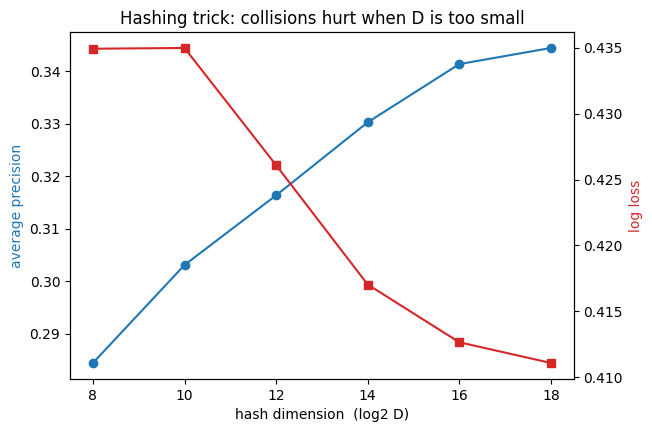

In [10]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
xs = [int(np.log2(d)) for d in Ds]
ax1.plot(xs, ap_by_D, "-o", color="tab:blue")
ax1.set_xlabel("hash dimension  (log2 D)")
ax1.set_ylabel("average precision", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(xs, ll_by_D, "-s", color="tab:red")
ax2.set_ylabel("log loss", color="tab:red")
plt.title("Hashing trick: collisions hurt when D is too small")
plt.show()

## Task 6 - Calibration

A good *ranking* is not enough for ad bidding; the predicted probabilities must mean what they say. Build a reliability curve.

In [11]:
def reliability_curve(y, p, n_bins=10):
    """Return mean prediction and empirical rate for each non-empty bin."""
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    bin_ids = np.minimum((p * n_bins).astype(int), n_bins - 1)
    mean_predicted, empirical_rate = [], []
    for k in range(n_bins):
        mask = bin_ids == k
        if mask.any():
            mean_predicted.append(p[mask].mean())
            empirical_rate.append(y[mask].mean())
    return np.asarray(mean_predicted), np.asarray(empirical_rate)


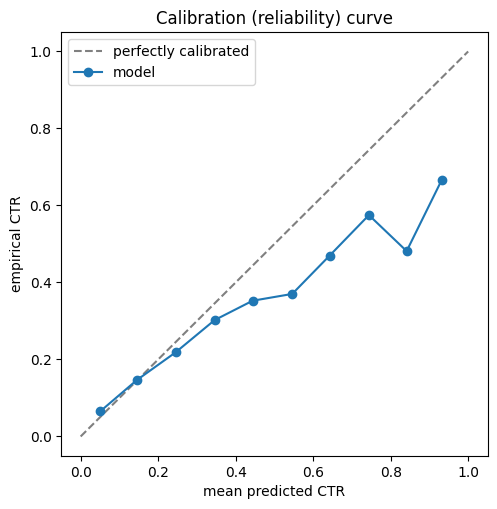

In [12]:
mp, emp = reliability_curve(y_test, p_te, n_bins=10)
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
plt.plot(mp, emp, "-o", label="model")
plt.xlabel("mean predicted CTR"); plt.ylabel("empirical CTR")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.show()

In [13]:
best_ap_i = int(np.argmax(ap_by_D))
best_ll_i = int(np.argmin(ll_by_D))
print(f"Best AP: D=2^{int(np.log2(Ds[best_ap_i]))}, AP={ap_by_D[best_ap_i]:.4f}")
print(f"Best log-loss: D=2^{int(np.log2(Ds[best_ll_i]))}, log-loss={ll_by_D[best_ll_i]:.4f}")
print(f"Mean absolute calibration gap: {np.mean(np.abs(emp - mp)):.4f}")


Best AP: D=2^18, AP=0.3444
Best log-loss: D=2^18, log-loss=0.4111
Mean absolute calibration gap: 0.1320


## Conceptual questions

1. The click rate is ~17%. What accuracy does the trivial "always predict
   no-click" model get, and why is accuracy the wrong headline metric here?
   Why are log-loss, average precision, and the PR curve more informative?
2. The hashing trick replaces one-hot encoding of high-cardinality IDs. What do
   you gain (memory, handling unseen values at test time) and what do you lose
   (collisions)? From your D sweep, where does shrinking D start to hurt, and why?
3. Restate the gradient you derived and explain why a hashed example updates only
   a handful of weights. Why does that make this model scale to billions of
   features?
4. Read your calibration curve. Are the predicted probabilities calibrated? Why
   does ad ranking/bidding (which multiplies predicted CTR by a bid) *need*
   calibrated probabilities, not just a good ranking?
5. Name one way to handle the class imbalance (class weights, threshold tuning,
   negative downsampling, ...). How would it move the PR curve and the calibration?


1. **Accuracy and imbalance.** With a click rate near 17%, always predicting no-click gives about 83% accuracy but finds no clicks. Accuracy therefore hides failure on the minority class. Log-loss evaluates probability quality, average precision summarizes how well positives are ranked, and the PR curve shows the precision-recall tradeoff across thresholds.

2. **Hashing tradeoff.** Hashing fixes memory at \(O(D)\), avoids storing a vocabulary, and handles unseen values automatically. The loss is collisions: unrelated tokens may share a coefficient. The dimension sweep shows that very small \(D\) values hurt because collisions create interference; performance improves and eventually levels off as \(D\) grows.

3. **Gradient and sparse updates.** For one example, \(\nabla_{\mathbf w}\ell=(p-y)\mathbf{x}\) and \(\partial\ell/\partial b=p-y\). Since a row activates only one bucket per categorical column, only those few weights are changed. Runtime depends on the number of active fields instead of the total vocabulary, allowing the method to scale to extremely large sparse spaces.

4. **Calibration.** A reliability curve near the diagonal means predicted probabilities agree with observed click rates. Points above the diagonal indicate under-prediction, while points below indicate over-prediction. Ad bidding needs calibrated probabilities because expected value is often predicted CTR multiplied by a bid or conversion value. A model may rank ads correctly while still bidding poorly if its probability scale is wrong.

5. **Handling imbalance.** One option is class-weighted loss, which gives positive examples more influence. It generally raises recall, although precision can fall depending on the threshold. Since class weighting changes the effective class balance during training, the resulting probabilities may need post-hoc calibration before being interpreted as CTR.


## What to submit

- This notebook with every `# TODO` completed and run top to bottom (the synthetic
  generator makes it fully reproducible; swap in the real Avazu frame if you want).
- The gradient derivation, the PR curve, the D-sweep figure, and the calibration curve.
- Written answers to the five conceptual questions.

**Grading (100 pts):** hashing trick (15), gradient derivation (15), SGD logreg
(20), imbalance-aware metrics + PR curve (20), hash-dimension sweep (15),
calibration + answers (15).
